<a href="https://colab.research.google.com/github/LennardBehmann/Intro_ML_HW2/blob/main/ML_HW2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2 – Linear Regression with Gradient Descent

US Housing dataset.  
All models use an 80/20 training/evaluation split with `random_state=42`.  
Gradient descent is implemented from scratch. Built-in scaling is used only where allowed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/LennardBehmann/Intro_ML_HW2/refs/heads/main/Housing.csv'

df = pd.read_csv(url)

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [2]:
# Show all column names
print(df.columns)


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [3]:
# Show information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# Problem 1a

Predict house price using: `area`, `bedrooms`, `bathrooms`, `stories`, and `parking`.


In [4]:
X = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']].values
y = df['price'].values
df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']].head()

,area,bedrooms,bathrooms,stories,parking,price
0,7420,4,2,3,2,13300000
1,8960,4,4,4,3,12250000
2,9960,3,2,2,2,12250000
3,7500,4,2,2,3,12215000
4,7420,4,1,2,2,11410000


## Train/evaluation split


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42   #ensure that data split is the same every time to not mix up training and validation data if started new
)

#check
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (436, 5)
X_test: (109, 5)
y_train: (436,)
y_test: (109,)


## Add the bias column $x_0=1$


In [6]:
# write Number of training samples in m_train
m_train = X_train.shape[0]

# Create a column of ones for theta_0
X_0_train = np.ones((m_train, 1))

# Add the column of ones to X_train at the front
X_train = np.hstack((X_0_train, X_train))

# Number of test samples in m_test
m_test = X_test.shape[0]

# Create a column of ones for theta_0
X_0_test = np.ones((m_test, 1))

# Add the column of ones to X_test at the front
X_test = np.hstack((X_0_test, X_test))

#check
print(X_train[:5])
print("Shape:", X_train.shape)

[[1.000e+00 6.000e+03 3.000e+00 2.000e+00 4.000e+00 1.000e+00]
 [1.000e+00 7.200e+03 3.000e+00 2.000e+00 1.000e+00 3.000e+00]
 [1.000e+00 3.816e+03 2.000e+00 1.000e+00 1.000e+00 2.000e+00]
 [1.000e+00 2.610e+03 3.000e+00 1.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 3.750e+03 3.000e+00 1.000e+00 2.000e+00 0.000e+00]]
Shape: (436, 6)


## Cost function and gradient descent


In [7]:
def compute_cost(X, y, theta):
  #added length m to existing function
    m=len(y)

    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m) * np.sum(sqrErrors)
    return J

In [8]:
def gradient_descent(X_train, y_train, X_test, y_test, theta, alpha, iterations):

    # Number of training examples
    m = len(y_train)

    train_cost_history = np.zeros(iterations)
    test_cost_history = np.zeros(iterations)

    for i in range(iterations):

        # Training: calculate predictions and errors
        predictions = X_train.dot(theta)
        errors = np.subtract(predictions, y_train)

        # Calculate gradient and update theta
        sum_delta = (alpha / m) * X_train.transpose().dot(errors)
        theta -= sum_delta

        # Save training cost
        train_cost_history[i] = compute_cost(X_train, y_train, theta)

        # Save test cost, theta is NOT changed here
        test_cost_history[i] = compute_cost(X_test, y_test, theta)

    return theta, train_cost_history, test_cost_history

## Learning-rate exploration

The learning rates requested in the assignment (`0.01`, `0.05`, `0.1`) are first tested on the unscaled features.  
They diverge because the feature scales are very different. After clarification from the professor that smaller values are acceptable, smaller learning rates are explored.


In [9]:
# Test learning rates from the range requested in the assignment
learning_rates_required_1a = [0.01, 0.05, 0.1]
iterations = 1000

for alpha_test in learning_rates_required_1a:
    theta_test = np.zeros(6)

    # Suppress overflow warnings here because divergence is the behavior being tested
    with np.errstate(over='ignore', invalid='ignore'):
        theta_test, train_cost_test, test_cost_test = gradient_descent(
            X_train, y_train,
            X_test, y_test,
            theta_test,
            alpha_test,
            iterations
        )

    if np.isfinite(test_cost_test[-1]):
        print("Learning Rate:", alpha_test)
        print("Final Training Cost:", train_cost_test[-1])
        print("Final Validation Cost:", test_cost_test[-1])
    else:
        print("Learning Rate:", alpha_test, "-> diverged (NaN/Inf)")
    print()


Learning Rate: 0.01 -> diverged (NaN/Inf)

Learning Rate: 0.05 -> diverged (NaN/Inf)

Learning Rate: 0.1 -> diverged (NaN/Inf)



In [10]:
# Compare smaller learning rates after clarification from the professor
learning_rates_1a = [1e-9, 5e-9, 1e-8, 5e-8, 1e-7]
iterations = 1000

for alpha_test in learning_rates_1a:
    theta_test = np.zeros(6)

    with np.errstate(over='ignore', invalid='ignore'):
        theta_test, train_cost_test, test_cost_test = gradient_descent(
            X_train, y_train,
            X_test, y_test,
            theta_test,
            alpha_test,
            iterations
        )

    print("Learning Rate:", alpha_test)
    print("Final Training Cost:", train_cost_test[-1])
    print("Final Validation Cost:", test_cost_test[-1])
    print("Theta:", theta_test)
    print()


Learning Rate: 1e-09
Final Training Cost: 1589372434533.0518
Final Validation Cost: 2034070237553.1885
Theta: [5.25190152e-01 8.37930064e+02 1.83467039e+00 9.41126654e-01
 1.43762692e+00 4.13349336e-01]

Learning Rate: 5e-09
Final Training Cost: 1589355415209.5642
Final Validation Cost: 2034054668277.4243
Theta: [  2.07600064 837.92477992   7.519055     3.98704748   6.19386107
   1.6219138 ]

Learning Rate: 1e-08
Final Training Cost: 1589334141560.2695
Final Validation Cost: 2034035207146.5747
Theta: [  4.01448962 837.91817466  14.62444416   7.79441183  12.13908431
   3.13261148]

Learning Rate: 5e-08
Final Training Cost: 1589163972566.6934
Final Validation Cost: 2033879536650.746
Theta: [ 19.5214362  837.86533567  71.46389357  38.25185972  59.69809289
  15.21787745]

Learning Rate: 1e-07
Final Training Cost: nan
Final Validation Cost: nan
Theta: [nan nan nan nan nan nan]



## Final model for Problem 1a

Among the stable learning rates, `5e-8` gives the lowest final validation loss.  
`1e-7` already diverges, so `5e-8` is selected.


In [11]:
# Reset theta before a new training run
theta = np.zeros(6)

iterations = 1000
alpha = 5e-8

theta, train_cost_history, test_cost_history = gradient_descent(
    X_train,
    y_train,
    X_test,
    y_test,
    theta,
    alpha,
    iterations
)

print("Theta:", theta)
print("First training cost:", train_cost_history[0])
print("Final training cost:", train_cost_history[-1])

print("First test cost:", test_cost_history[0])
print("Final test cost:", test_cost_history[-1])

Theta: [ 19.5214362  837.86533567  71.46389357  38.25185972  59.69809289
  15.21787745]
First training cost: 5180602364023.897
Final training cost: 1589163972566.6934
First test cost: 4192671389144.156
Final test cost: 2033879536650.746


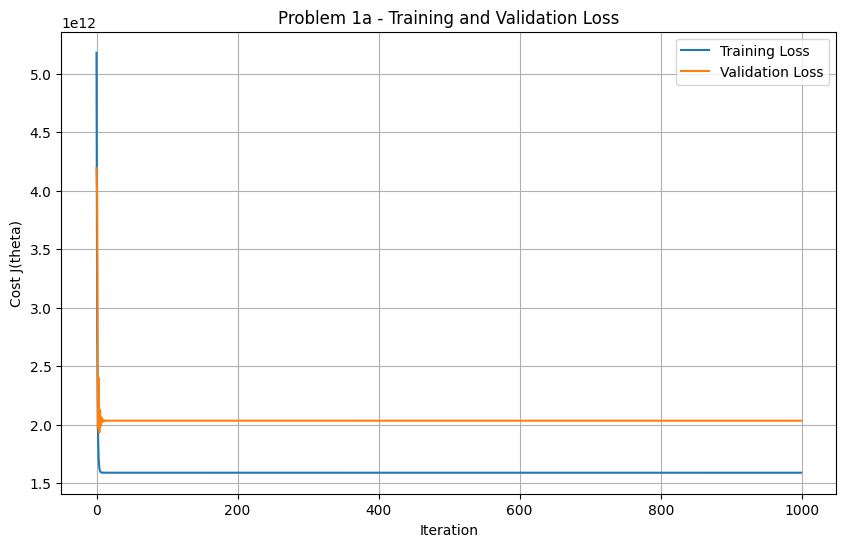

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(train_cost_history, label='Training Loss')
plt.plot(test_cost_history, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Problem 1a - Training and Validation Loss')

plt.legend()
plt.grid(True)
plt.show()


# Problem 1b

Repeat the model using eleven input features. Binary `yes/no` variables are encoded as `1/0`.


## Encode binary features


In [13]:
df_1b = df.copy()
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]
for column in binary_columns:
    df_1b[column] = df_1b[column].map({'yes': 1, 'no': 0})

## Create feature matrix and target


In [14]:
features_1b = [
    'area',
    'bedrooms',
    'bathrooms',
    'stories',
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'parking',
    'prefarea'
]

X_1b = df_1b[features_1b].values
y_1b = df_1b['price'].values

In [15]:
print(X_1b[:5])
print("Shape:", X_1b.shape)

[[7420    4    2    3    1    0    0    0    1    2    1]
 [8960    4    4    4    1    0    0    0    1    3    0]
 [9960    3    2    2    1    0    1    0    0    2    1]
 [7500    4    2    2    1    0    1    0    1    3    1]
 [7420    4    1    2    1    1    1    0    1    2    0]]
Shape: (545, 11)


## Train/evaluation split


In [16]:
X_1b_train, X_1b_test, y_1b_train, y_1b_test = train_test_split(
    X_1b,
    y_1b,
    test_size=0.2,
    random_state=42
)

In [17]:
#check
print(X_1b_train.shape)
print(X_1b_test.shape)
print(y_1b_train.shape)
print(y_1b_test.shape)

(436, 11)
(109, 11)
(436,)
(109,)


## Add the bias column $x_0=1$


In [18]:
# Number of training samples
m_train_1b = X_1b_train.shape[0]

# Create a column of ones for theta_0
X_0_train_1b = np.ones((m_train_1b, 1))

# Add the column of ones to X_1b_train
X_1b_train = np.hstack((X_0_train_1b, X_1b_train))

# Number of test samples
m_test_1b = X_1b_test.shape[0]

# Create a column of ones for theta_0
X_0_test_1b = np.ones((m_test_1b, 1))

# Add the column of ones to X_1b_test
X_1b_test = np.hstack((X_0_test_1b, X_1b_test))

#check
print(X_1b_train[:5])
print("Training shape:", X_1b_train.shape)
print("Test shape:", X_1b_test.shape)

[[1.000e+00 6.000e+03 3.000e+00 2.000e+00 4.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 1.000e+00 0.000e+00]
 [1.000e+00 7.200e+03 3.000e+00 2.000e+00 1.000e+00 1.000e+00 0.000e+00
  1.000e+00 0.000e+00 1.000e+00 3.000e+00 0.000e+00]
 [1.000e+00 3.816e+03 2.000e+00 1.000e+00 1.000e+00 1.000e+00 0.000e+00
  1.000e+00 0.000e+00 1.000e+00 2.000e+00 0.000e+00]
 [1.000e+00 2.610e+03 3.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  1.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00]
 [1.000e+00 3.750e+03 3.000e+00 1.000e+00 2.000e+00 1.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]]
Training shape: (436, 12)
Test shape: (109, 12)


## Learning-rate exploration

The same learning-rate strategy as in Problem 1a is used.


In [19]:
# Test learning rates from the range requested in the assignment
learning_rates_required_1b = [0.01, 0.05, 0.1]
iterations = 1000

for alpha_test in learning_rates_required_1b:
    theta_test = np.zeros(12)

    with np.errstate(over='ignore', invalid='ignore'):
        theta_test, train_cost_test, test_cost_test = gradient_descent(
            X_1b_train, y_1b_train,
            X_1b_test, y_1b_test,
            theta_test,
            alpha_test,
            iterations
        )

    if np.isfinite(test_cost_test[-1]):
        print("Learning Rate:", alpha_test)
        print("Final Training Cost:", train_cost_test[-1])
        print("Final Validation Cost:", test_cost_test[-1])
    else:
        print("Learning Rate:", alpha_test, "-> diverged (NaN/Inf)")
    print()


Learning Rate: 0.01 -> diverged (NaN/Inf)

Learning Rate: 0.05 -> diverged (NaN/Inf)

Learning Rate: 0.1 -> diverged (NaN/Inf)



In [20]:
# Compare smaller learning rates
learning_rates_1b = [1e-9, 5e-9, 1e-8, 5e-8, 1e-7]
iterations = 1000

for alpha_test in learning_rates_1b:
    theta_test = np.zeros(12)

    with np.errstate(over='ignore', invalid='ignore'):
        theta_test, train_cost_test, test_cost_test = gradient_descent(
            X_1b_train, y_1b_train,
            X_1b_test, y_1b_test,
            theta_test,
            alpha_test,
            iterations
        )

    print("Learning Rate:", alpha_test)
    print("Final Training Cost:", train_cost_test[-1])
    print("Final Validation Cost:", test_cost_test[-1])
    print("Theta:", theta_test)
    print()


Learning Rate: 1e-09
Final Training Cost: 1589372027230.0
Final Validation Cost: 2034069873883.0977
Theta: [5.25190092e-01 8.37929945e+02 1.83467020e+00 9.41126576e-01
 1.43762680e+00 4.55244427e-01 1.51525272e-01 3.27136506e-01
 5.71614141e-02 3.65255486e-01 4.13349299e-01 1.88677526e-01]

Learning Rate: 5e-09
Final Training Cost: 1589353697697.9565
Final Validation Cost: 2034053157678.6277
Theta: [2.07599986e+00 8.37924280e+02 7.51905250e+00 3.98704641e+00
 6.19385939e+00 1.78059976e+00 6.43412812e-01 1.43434381e+00
 2.58284480e-01 1.63392194e+00 1.62191333e+00 7.94059515e-01]

Learning Rate: 1e-08
Final Training Cost: 1589330786332.0654
Final Validation Cost: 2034032262922.121
Theta: [4.01448681e+00 8.37917199e+02 1.46244351e+01 7.79440799e+00
 1.21390782e+01 3.43727661e+00 1.25826965e+00 2.81834376e+00
 5.09686635e-01 3.21974528e+00 3.13260981e+00 1.55078495e+00]

Learning Rate: 5e-08
Final Training Cost: 1589147517369.4792
Final Validation Cost: 2033865124829.9385
Theta: [ 19.5213

## Final model for Problem 1b

`5e-8` again gives the lowest validation loss among the stable tested values.  
The validation loss is only slightly lower than in Problem 1a.


In [21]:
# Reset theta for Problem 1b
alpha = 5e-8
iterations = 1000
theta_1b = np.zeros(12)

theta_1b, train_cost_history_1b, test_cost_history_1b = gradient_descent(
    X_1b_train,
    y_1b_train,
    X_1b_test,
    y_1b_test,
    theta_1b,
    alpha,
    iterations
)

In [22]:
print("Theta:", theta_1b)

print("First training cost:", train_cost_history_1b[0])
print("Final training cost:", train_cost_history_1b[-1])

print("First test cost:", test_cost_history_1b[0])
print("Final test cost:", test_cost_history_1b[-1])

Theta: [ 19.52137202 837.8605538   71.46368598  38.25177155  59.69795215
  16.68999833   6.1770207   13.88997645   2.52083679  15.90594321
  15.21783945   7.60450658]
First training cost: 5180602926081.769
Final training cost: 1589147517369.4792
First test cost: 4192671840465.136
Final test cost: 2033865124829.9385


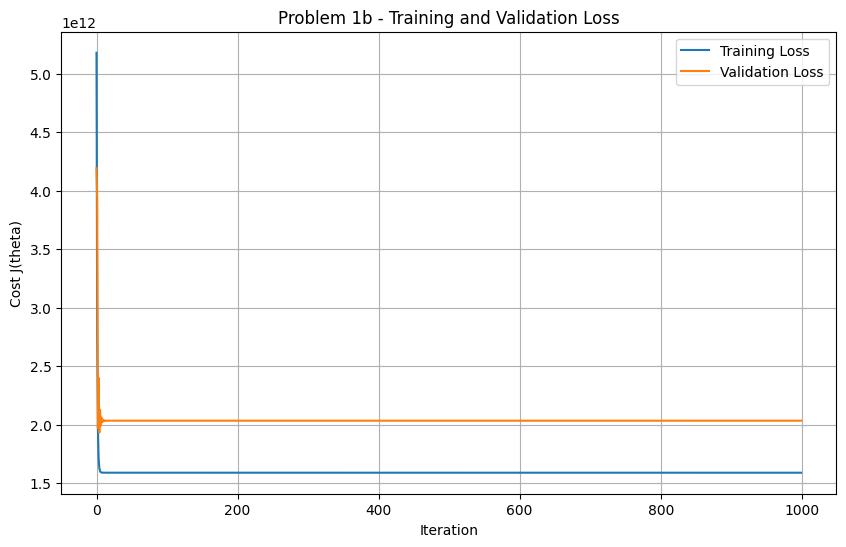

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(train_cost_history_1b, label='Training Loss')
plt.plot(test_cost_history_1b, label='Validation Loss')

plt.xlabel('Iteration')
plt.ylabel('Cost J(theta)')
plt.title('Problem 1b - Training and Validation Loss')

plt.legend()
plt.grid(True)
plt.show()


# Problem 2a

Repeat Problem 1a using two separate preprocessing approaches:
1. Min-Max normalization
2. Standardization

The output `price` is not scaled.


## Split the original five-feature data


In [24]:
X_2a_train, X_2a_test, y_2a_train, y_2a_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42   #ensure that data split is the same every time to not mix up training and validation data if started new
)

#check
print("X_train:", X_2a_train.shape)
print("X_test:", X_2a_test.shape)
print("y_train:", y_2a_train.shape)
print("y_test:", y_2a_test.shape)

X_train: (436, 5)
X_test: (109, 5)
y_train: (436,)
y_test: (109,)


## Create separate copies for normalization and standardization


In [25]:
X_2a_test_norm = X_2a_test.copy()
X_2a_test_stand = X_2a_test.copy()
X_2a_train_norm = X_2a_train.copy()
X_2a_train_stand = X_2a_train.copy()

#check
print("X_2a_test_norm:", X_2a_test_norm.shape)
print("X_2a_test_stand:", X_2a_test_stand.shape)
print("X_2a_train_norm:", X_2a_train_norm.shape)
print("X_2a_train_stand:", X_2a_train_stand.shape)

X_2a_test_norm: (109, 5)
X_2a_test_stand: (109, 5)
X_2a_train_norm: (436, 5)
X_2a_train_stand: (436, 5)


## Min-Max normalization


In [26]:
#normalize function
def normalize(X):
    min_vals = np.min(X, axis=0)
    max_vals = np.max(X, axis=0)

    X_norm = (X - min_vals) / (max_vals - min_vals)

    return X_norm, min_vals, max_vals


In [27]:
X_2a_train_norm, min_vals_2a, max_vals_2a = normalize(X_2a_train_norm)

X_2a_test_norm = (
    X_2a_test_norm - min_vals_2a
) / (
    max_vals_2a - min_vals_2a
)

In [28]:
print(X_2a_train_norm[:5])
print(X_2a_test_norm[:5])

[[0.29896907 0.4        0.33333333 1.         0.33333333]
 [0.3814433  0.4        0.33333333 0.         1.        ]
 [0.14886598 0.2        0.         0.         0.66666667]
 [0.06597938 0.4        0.         0.33333333 0.        ]
 [0.1443299  0.4        0.         0.33333333 0.        ]]
[[0.29209622 0.6        0.33333333 0.33333333 0.33333333]
 [0.33333333 0.4        0.33333333 0.66666667 0.        ]
 [0.16426117 0.2        0.         0.         0.        ]
 [0.23024055 0.4        0.         0.33333333 0.        ]
 [0.15876289 0.4        0.         0.         0.        ]]


### Add bias column to normalized data


In [29]:
# Add bias column to normalized training and test data

# Number of training samples
m_train_2a_norm = X_2a_train_norm.shape[0]

# Create column of ones for theta_0
bias_train_2a_norm = np.ones((m_train_2a_norm, 1))

# Add bias column to the front
X_2a_train_norm_bias = np.hstack(
    (bias_train_2a_norm, X_2a_train_norm)
)


# Number of test samples
m_test_2a_norm = X_2a_test_norm.shape[0]

# Create column of ones for theta_0
bias_test_2a_norm = np.ones((m_test_2a_norm, 1))

# Add bias column to the front
X_2a_test_norm_bias = np.hstack(
    (bias_test_2a_norm, X_2a_test_norm)
)


# Check
print("Normalized training data with bias:")
print(X_2a_train_norm_bias[:5])
print("Training shape:", X_2a_train_norm_bias.shape)

print("\nNormalized test data with bias:")
print(X_2a_test_norm_bias[:5])
print("Test shape:", X_2a_test_norm_bias.shape)

Normalized training data with bias:
[[1.         0.29896907 0.4        0.33333333 1.         0.33333333]
 [1.         0.3814433  0.4        0.33333333 0.         1.        ]
 [1.         0.14886598 0.2        0.         0.         0.66666667]
 [1.         0.06597938 0.4        0.         0.33333333 0.        ]
 [1.         0.1443299  0.4        0.         0.33333333 0.        ]]
Training shape: (436, 6)

Normalized test data with bias:
[[1.         0.29209622 0.6        0.33333333 0.33333333 0.33333333]
 [1.         0.33333333 0.4        0.33333333 0.66666667 0.        ]
 [1.         0.16426117 0.2        0.         0.         0.        ]
 [1.         0.23024055 0.4        0.         0.33333333 0.        ]
 [1.         0.15876289 0.4        0.         0.         0.        ]]
Test shape: (109, 6)


### Compare learning rates


Learning Rate: 0.01
Final Training Cost: 849748793747.9463
Final Validation Cost: 1458033578362.7144



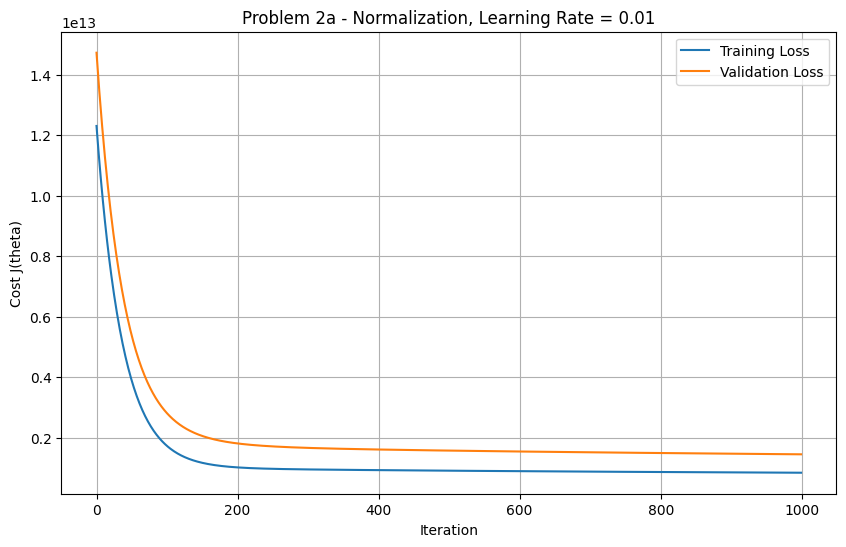

Learning Rate: 0.05
Final Training Cost: 704035112745.0892
Final Validation Cost: 1196908120183.3801



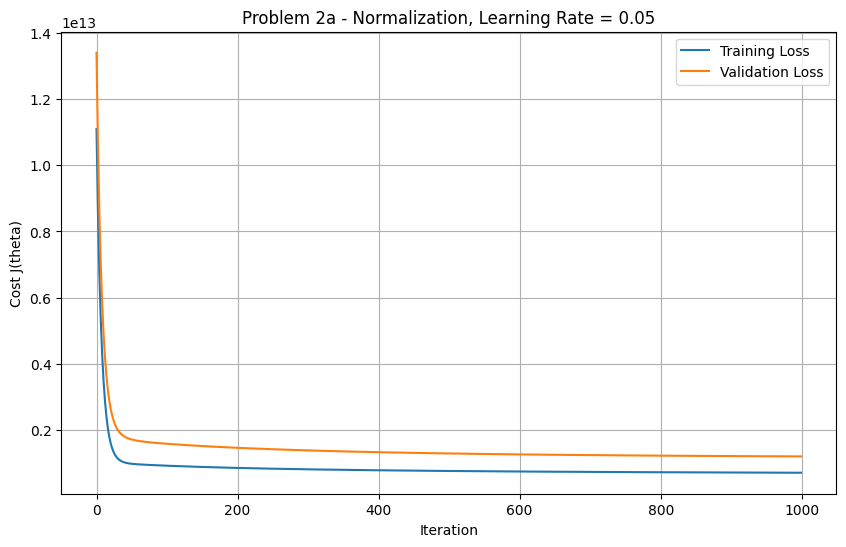

Learning Rate: 0.1
Final Training Cost: 679326731187.338
Final Validation Cost: 1156827430615.011



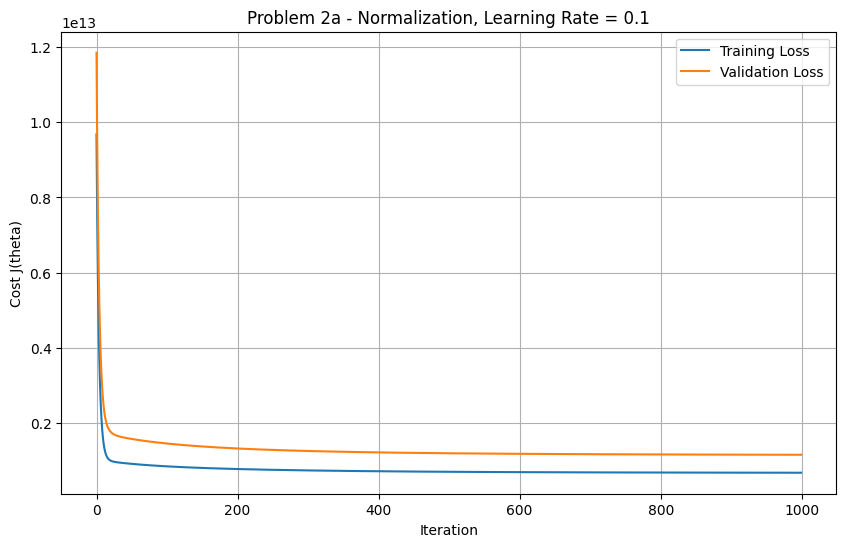

In [30]:
learning_rates = [0.01, 0.05, 0.1]
iterations = 1000

for alpha in learning_rates:

    # Reset theta for every learning rate
    theta_2a_norm = np.zeros(6)

    # Train model
    theta_2a_norm, train_cost_history_2a_norm, test_cost_history_2a_norm = gradient_descent(
        X_2a_train_norm_bias,
        y_2a_train,
        X_2a_test_norm_bias,
        y_2a_test,
        theta_2a_norm,
        alpha,
        iterations
    )

    # Print results
    print("Learning Rate:", alpha)
    print("Final Training Cost:", train_cost_history_2a_norm[-1])
    print("Final Validation Cost:", test_cost_history_2a_norm[-1])
    print()

    # Plot
    plt.figure(figsize=(10, 6))

    plt.plot(train_cost_history_2a_norm, label='Training Loss')
    plt.plot(test_cost_history_2a_norm, label='Validation Loss')

    plt.xlabel('Iteration')
    plt.ylabel('Cost J(theta)')
    plt.title(f'Problem 2a - Normalization, Learning Rate = {alpha}')

    plt.legend()
    plt.grid(True)

    plt.show()

## Standardization


In [31]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit scaler only on training data
scaler.fit(X_2a_train_stand)

# Standardize training and test data
X_2a_train_stand = scaler.transform(X_2a_train_stand)
X_2a_test_stand = scaler.transform(X_2a_test_stand)

# Check results
print(X_2a_train_stand[:5])
print("Training shape:", X_2a_train_stand.shape)

print(X_2a_test_stand[:5])
print("Test shape:", X_2a_test_stand.shape)

[[ 0.38416819  0.05527092  1.53917323  2.58764353  0.36795665]
 [ 0.9291807   0.05527092  1.53917323 -0.91249891  2.70998729]
 [-0.60775457 -1.28351359 -0.5579503  -0.91249891  1.53897197]
 [-1.15549214  0.05527092 -0.5579503   0.25421524 -0.80305867]
 [-0.63773026  0.05527092 -0.5579503   0.25421524 -0.80305867]]
Training shape: (436, 5)
[[ 0.33875048  1.39405543  1.53917323  0.25421524  0.36795665]
 [ 0.61125674  0.05527092  1.53917323  1.42092939 -0.80305867]
 [-0.5060189  -1.28351359 -0.5579503  -0.91249891 -0.80305867]
 [-0.0700089   0.05527092 -0.5579503   0.25421524 -0.80305867]
 [-0.54235307  0.05527092 -0.5579503  -0.91249891 -0.80305867]]
Test shape: (109, 5)


### Add bias column to standardized data


In [32]:
# Add bias column to standardized training and test data

# Number of training samples
m_train_2a_stand = X_2a_train_stand.shape[0]

# Create column of ones for theta_0
bias_train_2a_stand = np.ones((m_train_2a_stand, 1))

# Add bias column to the front
X_2a_train_stand_bias = np.hstack(
    (bias_train_2a_stand, X_2a_train_stand)
)


# Number of test samples
m_test_2a_stand = X_2a_test_stand.shape[0]

# Create column of ones for theta_0
bias_test_2a_stand = np.ones((m_test_2a_stand, 1))

# Add bias column to the front
X_2a_test_stand_bias = np.hstack(
    (bias_test_2a_stand, X_2a_test_stand)
)


# Check
print("Stanardized training data with bias:")
print(X_2a_train_stand_bias[:5])
print("Training shape:", X_2a_train_stand_bias.shape)

print("\nStandardized test data with bias:")
print(X_2a_test_stand_bias[:5])
print("Test shape:", X_2a_test_stand_bias.shape)

Stanardized training data with bias:
[[ 1.          0.38416819  0.05527092  1.53917323  2.58764353  0.36795665]
 [ 1.          0.9291807   0.05527092  1.53917323 -0.91249891  2.70998729]
 [ 1.         -0.60775457 -1.28351359 -0.5579503  -0.91249891  1.53897197]
 [ 1.         -1.15549214  0.05527092 -0.5579503   0.25421524 -0.80305867]
 [ 1.         -0.63773026  0.05527092 -0.5579503   0.25421524 -0.80305867]]
Training shape: (436, 6)

Standardized test data with bias:
[[ 1.          0.33875048  1.39405543  1.53917323  0.25421524  0.36795665]
 [ 1.          0.61125674  0.05527092  1.53917323  1.42092939 -0.80305867]
 [ 1.         -0.5060189  -1.28351359 -0.5579503  -0.91249891 -0.80305867]
 [ 1.         -0.0700089   0.05527092 -0.5579503   0.25421524 -0.80305867]
 [ 1.         -0.54235307  0.05527092 -0.5579503  -0.91249891 -0.80305867]]
Test shape: (109, 6)


### Compare learning rates


Learning Rate: 0.01
Final Training Cost: 675004510848.4789
Final Validation Cost: 1146408168889.5422



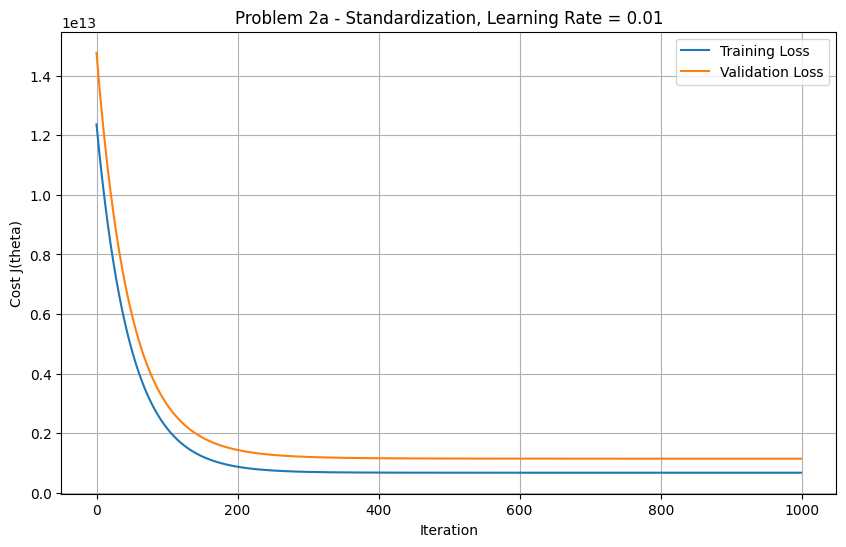

Learning Rate: 0.05
Final Training Cost: 675004105663.2902
Final Validation Cost: 1146360772862.6858



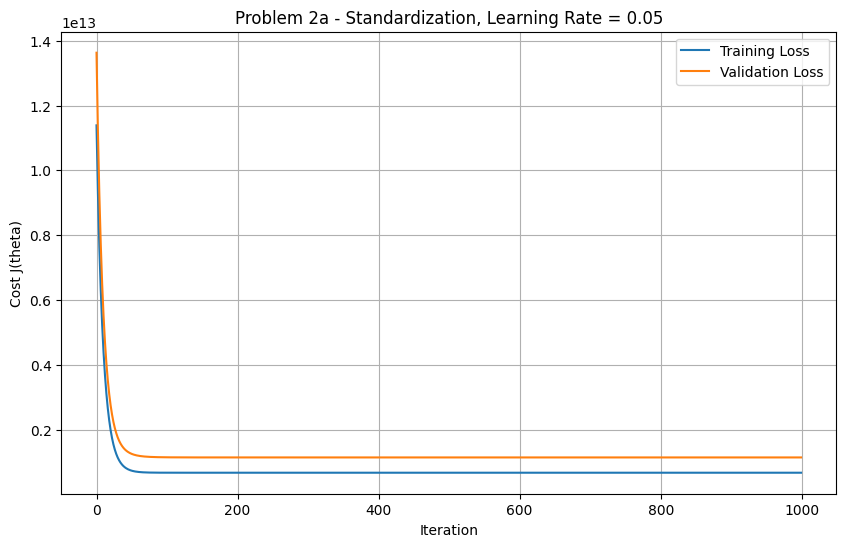

Learning Rate: 0.1
Final Training Cost: 675004105663.2902
Final Validation Cost: 1146360772862.6836



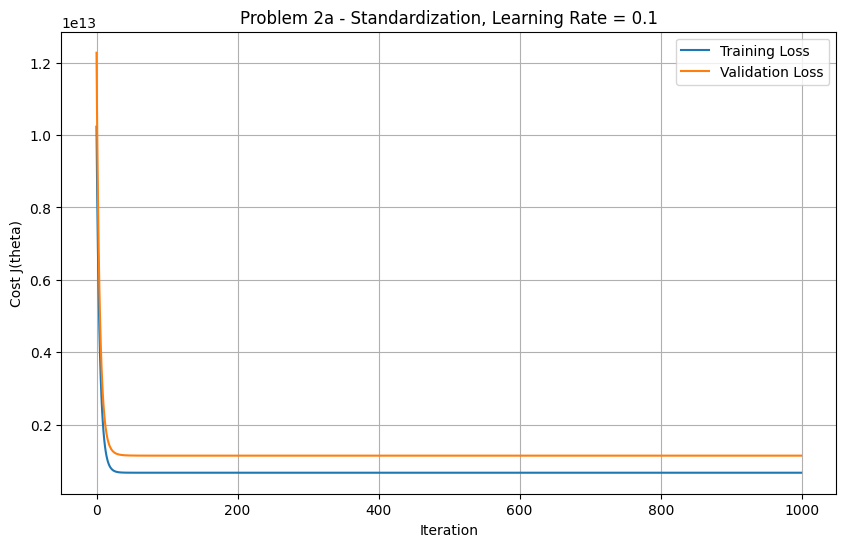

In [33]:
learning_rates = [0.01, 0.05, 0.1]
iterations = 1000

for alpha in learning_rates:

    # Reset theta for every learning rate
    theta_2a_stand = np.zeros(6)

    # Train model
    theta_2a_stand, train_cost_history_2a_stand, test_cost_history_2a_stand = gradient_descent(
        X_2a_train_stand_bias,
        y_2a_train,
        X_2a_test_stand_bias,
        y_2a_test,
        theta_2a_stand,
        alpha,
        iterations
    )

    # Print results
    print("Learning Rate:", alpha)
    print("Final Training Cost:", train_cost_history_2a_stand[-1])
    print("Final Validation Cost:", test_cost_history_2a_stand[-1])
    print()

    # Plot
    plt.figure(figsize=(10, 6))

    plt.plot(train_cost_history_2a_stand, label='Training Loss')
    plt.plot(test_cost_history_2a_stand, label='Validation Loss')

    plt.xlabel('Iteration')
    plt.ylabel('Cost J(theta)')
    plt.title(f'Problem 2a - Standardization, Learning Rate = {alpha}')

    plt.legend()
    plt.grid(True)

    plt.show()

## Problem 2a result

Standardization gives the lowest validation loss (about $1.14636\times10^{12}$) and converges quickly and stably.  
Therefore, standardization is selected for Problem 3a.


# Problem 2b

Repeat Problem 1b using normalization and standardization on the eleven input features.  
The output `price` is not scaled.


In [34]:
df_2b = df_1b.copy()
df_2b.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


## Create feature matrix and target


In [35]:
X_2b = df_2b[['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']].values
y_2b = df_2b['price'].values

#check
print(X_2b[:5])
print("X shape:", X_2b.shape)
print("y shape:", y_2b.shape)




[[7420    4    2    3    1    0    0    0    1    2    1]
 [8960    4    4    4    1    0    0    0    1    3    0]
 [9960    3    2    2    1    0    1    0    0    2    1]
 [7500    4    2    2    1    0    1    0    1    3    1]
 [7420    4    1    2    1    1    1    0    1    2    0]]
X shape: (545, 11)
y shape: (545,)


## Train/evaluation split


In [36]:
X_2b_train, X_2b_test, y_2b_train, y_2b_test = train_test_split(
    X_2b,
    y_2b,
    test_size=0.2,
    random_state=42   #ensure that data split is the same every time to not mix up training and validation data if started new
)

#check
print("X_train:", X_2b_train.shape)
print("X_test:", X_2b_test.shape)
print("y_train:", y_2b_train.shape)
print("y_test:", y_2b_test.shape)

X_train: (436, 11)
X_test: (109, 11)
y_train: (436,)
y_test: (109,)


## Create separate copies for both scaling approaches


In [37]:
X_2b_train_norm=X_2b_train.copy()
X_2b_test_norm=X_2b_test.copy()
X_2b_train_stand=X_2b_train.copy()
X_2b_test_stand=X_2b_test.copy()

## Normalize and standardize using training-set statistics only


In [38]:
#normalization
X_2b_train_norm, min_vals_2b, max_vals_2b = normalize(X_2b_train_norm)
X_2b_test_norm = (X_2b_test_norm - min_vals_2b) / (max_vals_2b - min_vals_2b)

#standardization
scaler_2b = StandardScaler()
X_2b_train_stand = scaler_2b.fit_transform(X_2b_train_stand)
X_2b_test_stand = scaler_2b.transform(X_2b_test_stand)


## Normalized model


In [39]:
# Add bias column to normalized training and test data

# Training data
m_train_2b_norm = X_2b_train_norm.shape[0]

bias_train_2b_norm = np.ones((m_train_2b_norm, 1))

X_2b_train_norm_bias = np.hstack(
    (bias_train_2b_norm, X_2b_train_norm)
)


# Test data
m_test_2b_norm = X_2b_test_norm.shape[0]

bias_test_2b_norm = np.ones((m_test_2b_norm, 1))

X_2b_test_norm_bias = np.hstack(
    (bias_test_2b_norm, X_2b_test_norm)
)


# Check
print("Normalized training data with bias:")
print(X_2b_train_norm_bias[:5])
print("Training shape:", X_2b_train_norm_bias.shape)

print("\nNormalized test data with bias:")
print(X_2b_test_norm_bias[:5])
print("Test shape:", X_2b_test_norm_bias.shape)

Normalized training data with bias:
[[1.         0.29896907 0.4        0.33333333 1.         1.
  0.         0.         0.         1.         0.33333333 0.        ]
 [1.         0.3814433  0.4        0.33333333 0.         1.
  0.         1.         0.         1.         1.         0.        ]
 [1.         0.14886598 0.2        0.         0.         1.
  0.         1.         0.         1.         0.66666667 0.        ]
 [1.         0.06597938 0.4        0.         0.33333333 1.
  0.         1.         0.         0.         0.         1.        ]
 [1.         0.1443299  0.4        0.         0.33333333 1.
  0.         0.         0.         0.         0.         0.        ]]
Training shape: (436, 12)

Normalized test data with bias:
[[1.         0.29209622 0.6        0.33333333 0.33333333 0.
  0.         1.         0.         0.         0.33333333 0.        ]
 [1.         0.33333333 0.4        0.33333333 0.66666667 1.
  0.         0.         0.         1.         0.         1.        ]
 

Learning Rate: 0.01
Final Training Cost: 640942055907.615
Final Validation Cost: 1077541865435.6562



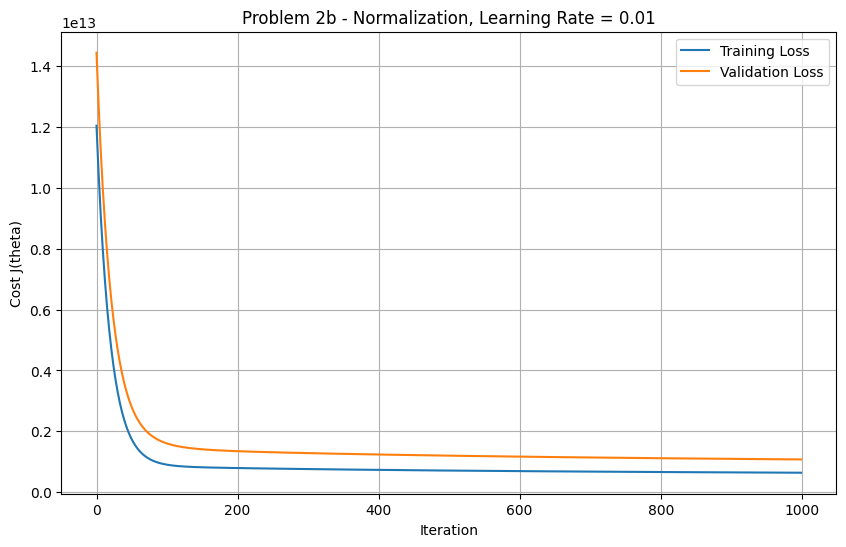

Learning Rate: 0.05
Final Training Cost: 519822018821.4629
Final Validation Cost: 900914192484.2476



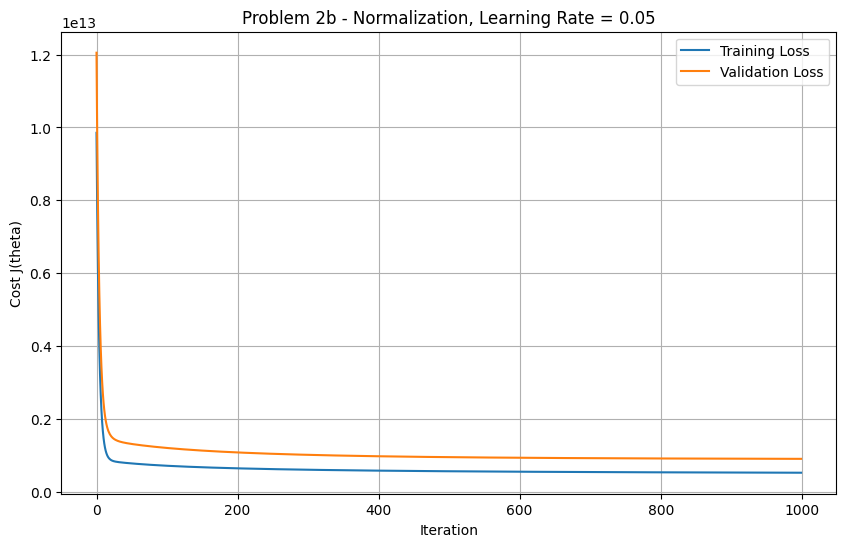

Learning Rate: 0.1
Final Training Cost: 500403900500.5455
Final Validation Cost: 891968202704.1312



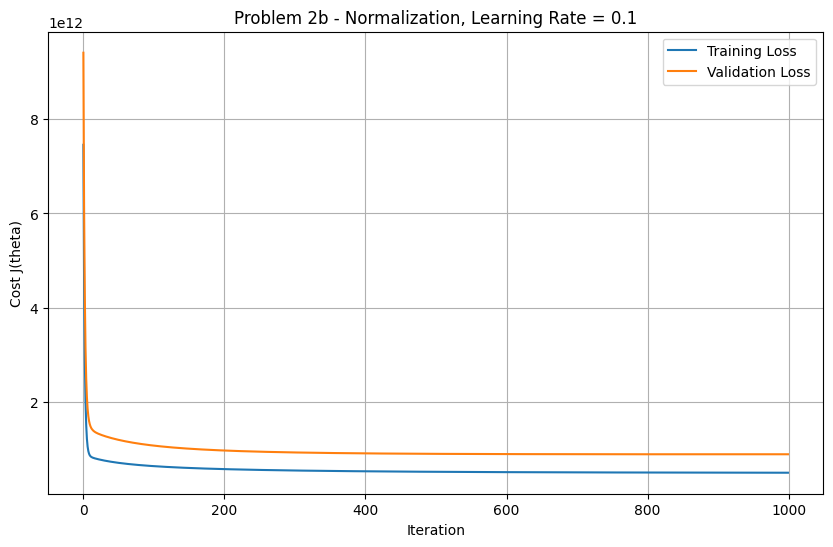

In [40]:
learning_rates = [0.01, 0.05, 0.1]
iterations = 1000

for alpha in learning_rates:

    # Reset theta for every learning rate
    theta_2b_norm = np.zeros(12)

    # Train model
    theta_2b_norm, train_cost_history_2b_norm, test_cost_history_2b_norm = gradient_descent(
        X_2b_train_norm_bias,
        y_2b_train,
        X_2b_test_norm_bias,
        y_2b_test,
        theta_2b_norm,
        alpha,
        iterations
    )

    # Print results
    print("Learning Rate:", alpha)
    print("Final Training Cost:", train_cost_history_2b_norm[-1])
    print("Final Validation Cost:", test_cost_history_2b_norm[-1])
    print()

    # Plot
    plt.figure(figsize=(10, 6))

    plt.plot(train_cost_history_2b_norm, label='Training Loss')
    plt.plot(test_cost_history_2b_norm, label='Validation Loss')

    plt.xlabel('Iteration')
    plt.ylabel('Cost J(theta)')
    plt.title(f'Problem 2b - Normalization, Learning Rate = {alpha}')

    plt.legend()
    plt.grid(True)

    plt.show()

## Standardized model


In [41]:
# Add bias column to standardized training and test data

# Training data
m_train_2b_stand = X_2b_train_stand.shape[0]

bias_train_2b_stand = np.ones((m_train_2b_stand, 1))

X_2b_train_stand_bias = np.hstack(
    (bias_train_2b_stand, X_2b_train_stand)
)


# Test data
m_test_2b_stand = X_2b_test_stand.shape[0]

bias_test_2b_stand = np.ones((m_test_2b_stand, 1))

X_2b_test_stand_bias = np.hstack(
    (bias_test_2b_stand, X_2b_test_stand)
)


# Check
print("Standardized training data with bias:")
print(X_2b_train_stand_bias[:5])
print("Training shape:", X_2b_train_stand_bias.shape)

print("\nStandardized test data with bias:")
print(X_2b_test_stand_bias[:5])
print("Test shape:", X_2b_test_stand_bias.shape)

Standardized training data with bias:
[[ 1.          0.38416819  0.05527092  1.53917323  2.58764353  0.40715525
  -0.46677307 -0.74642003 -0.23052136  1.50124327  0.36795665 -0.55262032]
 [ 1.          0.9291807   0.05527092  1.53917323 -0.91249891  0.40715525
  -0.46677307  1.33972825 -0.23052136  1.50124327  2.70998729 -0.55262032]
 [ 1.         -0.60775457 -1.28351359 -0.5579503  -0.91249891  0.40715525
  -0.46677307  1.33972825 -0.23052136  1.50124327  1.53897197 -0.55262032]
 [ 1.         -1.15549214  0.05527092 -0.5579503   0.25421524  0.40715525
  -0.46677307  1.33972825 -0.23052136 -0.66611456 -0.80305867  1.80956067]
 [ 1.         -0.63773026  0.05527092 -0.5579503   0.25421524  0.40715525
  -0.46677307 -0.74642003 -0.23052136 -0.66611456 -0.80305867 -0.55262032]]
Training shape: (436, 12)

Standardized test data with bias:
[[ 1.          0.33875048  1.39405543  1.53917323  0.25421524 -2.45606557
  -0.46677307  1.33972825 -0.23052136 -0.66611456  0.36795665 -0.55262032]
 [ 1. 

Learning Rate: 0.01
Final Training Cost: 496244544318.54205
Final Validation Cost: 900111363844.0186



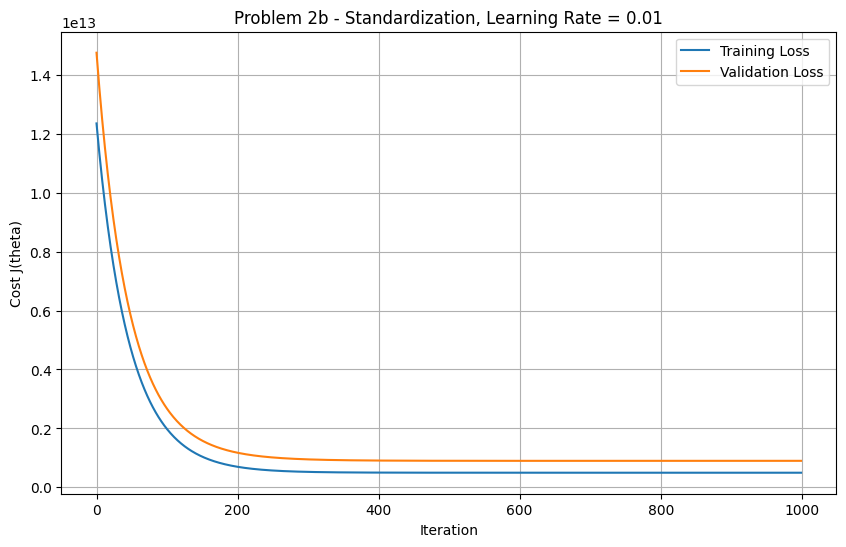

Learning Rate: 0.05
Final Training Cost: 496240500004.89264
Final Validation Cost: 900396859838.0833



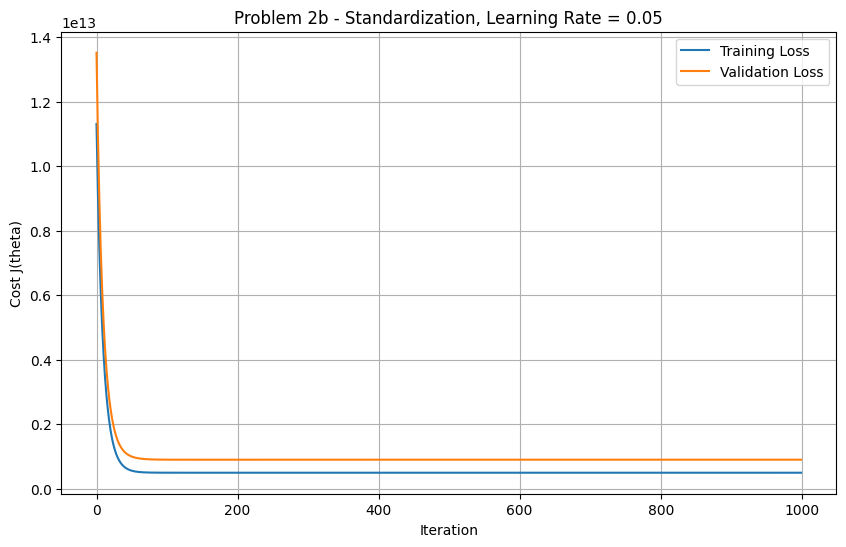

Learning Rate: 0.1
Final Training Cost: 496240500004.89264
Final Validation Cost: 900396859859.4866



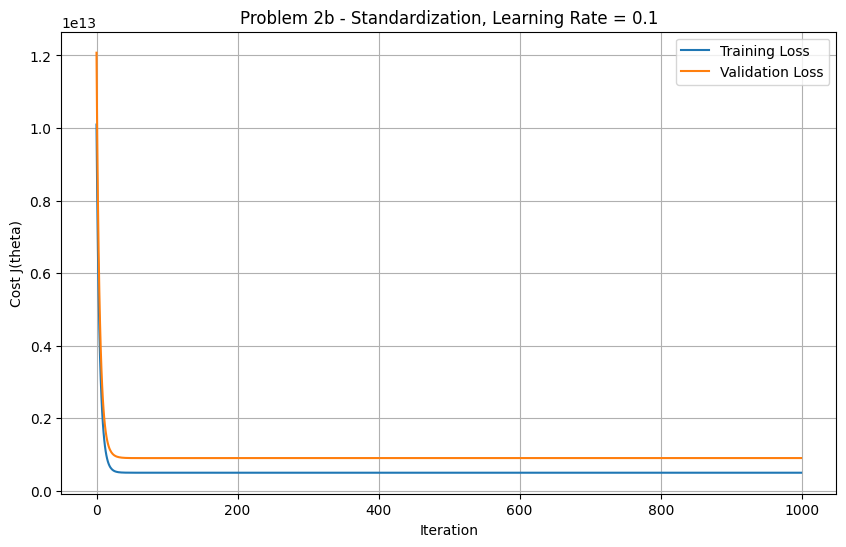

In [42]:
learning_rates = [0.01, 0.05, 0.1]
iterations = 1000

for alpha in learning_rates:

    # Reset theta for every learning rate
    theta_2b_stand = np.zeros(12)

    # Train model
    theta_2b_stand, train_cost_history_2b_stand, test_cost_history_2b_stand = gradient_descent(
        X_2b_train_stand_bias,
        y_2b_train,
        X_2b_test_stand_bias,
        y_2b_test,
        theta_2b_stand,
        alpha,
        iterations
    )

    # Print results
    print("Learning Rate:", alpha)
    print("Final Training Cost:", train_cost_history_2b_stand[-1])
    print("Final Validation Cost:", test_cost_history_2b_stand[-1])
    print()

    # Plot
    plt.figure(figsize=(10, 6))

    plt.plot(train_cost_history_2b_stand, label='Training Loss')
    plt.plot(test_cost_history_2b_stand, label='Validation Loss')

    plt.xlabel('Iteration')
    plt.ylabel('Cost J(theta)')
    plt.title(f'Problem 2b - Standardization, Learning Rate = {alpha}')

    plt.legend()
    plt.grid(True)

    plt.show()

## Problem 2b result

Standardization achieves the lower training loss, while normalization with `alpha = 0.1` achieves the lower validation loss (about $8.91968\times10^{11}$).  
Because validation performance is used to select the model for unseen data, normalization is selected for Problem 3b.


# Problem 3a

Add an L2 parameter penalty to the five-feature model using the best scaling approach from Problem 2a: **standardization**.


## Regularized cost function


In [43]:
def compute_cost_regularized(X, y, theta, lambda_value):

    m = len(y)

    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)

    # Exclude theta_0 (bias/intercept) from regularization
    regularization = lambda_value * np.sum(theta[1:] ** 2)

    J = 1 / (2 * m) * (np.sum(sqrErrors) + regularization)

    return J


## Regularized gradient descent


In [44]:
def gradient_descent_regularized(X_train, y_train, X_test, y_test, theta, alpha, iterations, lambda_value):

    # Number of training examples
    m = len(y_train)

    train_cost_history = np.zeros(iterations)
    test_cost_history = np.zeros(iterations)

    for i in range(iterations):

        # Training: calculate predictions and errors
        predictions = X_train.dot(theta)
        errors = np.subtract(predictions, y_train)

        # Regularization gradient
        regularization = lambda_value * theta.copy()

        # Do not regularize theta_0
        regularization[0] = 0

        # Calculate gradient and update theta
        sum_delta = (alpha / m) * (X_train.transpose().dot(errors)+regularization)
        theta -= sum_delta

        # Save training cost
        train_cost_history[i] = compute_cost_regularized(X_train, y_train, theta, lambda_value)

        # Save test cost, theta is NOT changed here
        test_cost_history[i] = compute_cost(X_test, y_test, theta)

    return theta, train_cost_history, test_cost_history

## Check: $\lambda=0$

When `lambda = 0`, the regularized implementation should produce the same result as the original gradient descent.


In [45]:
alpha = 0.05
iterations = 1000
lambda_value = 0

theta_normal = np.zeros(6)
theta_regularized = np.zeros(6)

theta_normal, train_cost_normal, test_cost_normal = gradient_descent(
    X_2a_train_stand_bias,
    y_2a_train,
    X_2a_test_stand_bias,
    y_2a_test,
    theta_normal,
    alpha,
    iterations
)

theta_regularized, train_cost_regularized, test_cost_regularized = gradient_descent_regularized(
    X_2a_train_stand_bias,
    y_2a_train,
    X_2a_test_stand_bias,
    y_2a_test,
    theta_regularized,
    alpha,
    iterations,
    lambda_value
)

print("Normal theta:")
print(theta_normal)

print("\nRegularized theta with lambda = 0:")
print(theta_regularized)

print("\nNormal final training cost:")
print(train_cost_normal[-1])

print("Regularized final training cost:")
print(train_cost_regularized[-1])

print("\nNormal final validation cost:")
print(test_cost_normal[-1])

print("Regularized final validation cost:")
print(test_cost_regularized[-1])


Normal theta:
[4706527.38532109  680058.42414123  112973.18562915  565408.61793598
  424354.81176349  288348.7726677 ]

Regularized theta with lambda = 0:
[4706527.38532109  680058.42414123  112973.18562915  565408.61793598
  424354.81176349  288348.7726677 ]

Normal final training cost:
675004105663.2902
Regularized final training cost:
675004105663.2902

Normal final validation cost:
1146360772862.6858
Regularized final validation cost:
1146360772862.6858


## Evaluate different regularization strengths


Lambda: 0
Theta: [4706527.38532109  680058.42414123  112973.18562915  565408.61793598
  424354.81176349  288348.7726677 ]
Final Training Cost: 675004105663.2902
Final Validation Cost: 1146360772862.6858

Lambda: 0.001
Theta: [4706527.38532109  680057.03561149  112973.88617824  565407.59696671
  424353.97757152  288348.72104349]
Final Training Cost: 675005319137.5055
Final Validation Cost: 1146361344107.7905

Lambda: 0.01
Theta: [4706527.38532109  680044.53915748  112980.19075567  565398.40848202
  424346.47007127  288348.25632417]
Final Training Cost: 675016240218.5042
Final Validation Cost: 1146366485461.9133

Lambda: 0.05
Theta: [4706527.38532109  679989.00619068  113008.20316684  565357.575971
  424313.10835524  288346.18869616]
Final Training Cost: 675064774285.6069
Final Validation Cost: 1146389339150.7886

Lambda: 0.1
Theta: [4706527.38532109  679919.60565602  113043.20047521  565306.5472641
  424271.41757478  288343.59909241]
Final Training Cost: 675125432525.6848
Final Validati

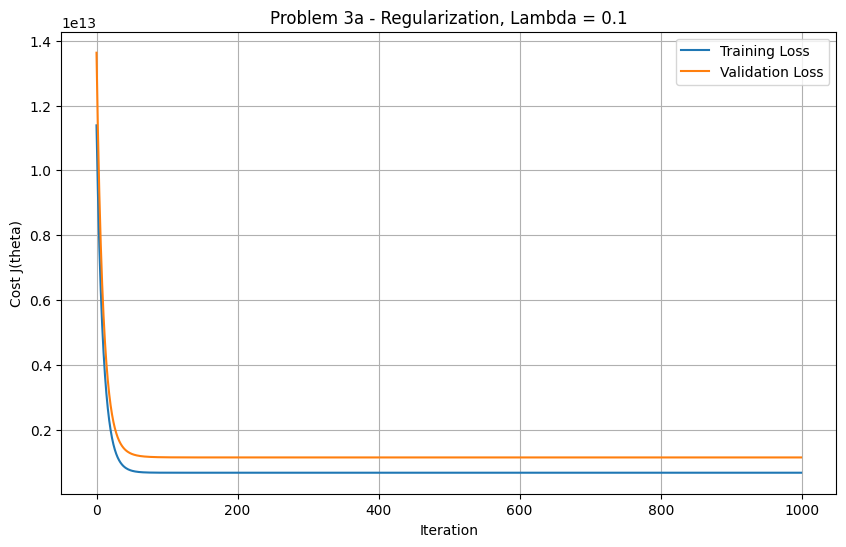

Lambda: 1
Theta: [4706527.38532109  678673.36548148  113669.70765831  564390.29003316
  423523.1347061   288296.02803672]
Final Training Cost: 676215509548.8854
Final Validation Cost: 1146933652803.8298

Lambda: 10
Theta: [4706527.38532109  666511.70061345  119590.63348318  555455.54722932
  416256.33592056  287725.37020698]
Final Training Cost: 686935784807.2144
Final Validation Cost: 1152228178686.8584



In [46]:
lambda_values_3a = [0, 0.001, 0.01, 0.05, 0.1, 1, 10]
alpha = 0.05
iterations = 1000

final_validation_losses_3a = []

for lambda_value in lambda_values_3a:
    theta_3a = np.zeros(6)

    theta_3a, train_cost_3a, test_cost_3a = gradient_descent_regularized(
        X_2a_train_stand_bias,
        y_2a_train,
        X_2a_test_stand_bias,
        y_2a_test,
        theta_3a,
        alpha,
        iterations,
        lambda_value
    )

    final_validation_losses_3a.append(test_cost_3a[-1])

    print("Lambda:", lambda_value)
    print("Theta:", theta_3a)
    print("Final Training Cost:", train_cost_3a[-1])
    print("Final Validation Cost:", test_cost_3a[-1])
    print()

    # Representative regularized training curve
    if lambda_value == 0.1:
        plt.figure(figsize=(10, 6))
        plt.plot(train_cost_3a, label='Training Loss')
        plt.plot(test_cost_3a, label='Validation Loss')
        plt.xlabel('Iteration')
        plt.ylabel('Cost J(theta)')
        plt.title('Problem 3a - Regularization, Lambda = 0.1')
        plt.legend()
        plt.grid(True)
        plt.show()


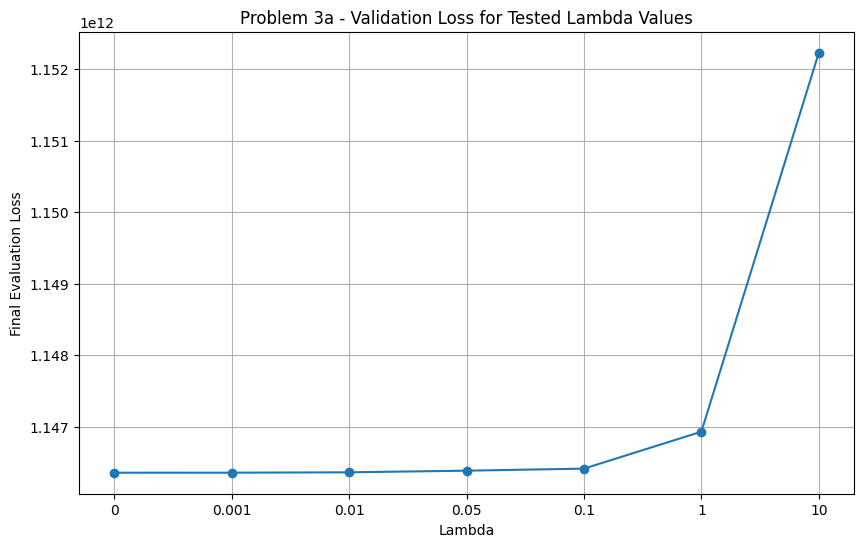

In [47]:
# Compare final validation loss for all tested lambda values
lambda_labels_3a = [str(value) for value in lambda_values_3a]

plt.figure(figsize=(10, 6))
plt.plot(lambda_labels_3a, final_validation_losses_3a, marker='o')

plt.xlabel('Lambda')
plt.ylabel('Final Evaluation Loss')
plt.title('Problem 3a - Validation Loss for Tested Lambda Values')
plt.grid(True)
plt.show()


## Problem 3a result

Increasing `lambda` reduces the magnitude of the regularized parameters, but does not improve validation performance.  
The lowest validation loss is obtained at `lambda = 0`; stronger regularization gradually worsens evaluation performance.


# Problem 3b

Add the same L2 penalty to the eleven-feature model using the best scaling approach from Problem 2b: **Min-Max normalization**.


Lambda: 0
Theta: [1848477.43551627 2997408.52706468  802331.69139496 2959618.99487472
 1248874.15133257  466323.28928175  278591.23057131  416674.9310782
  721736.68446843  830060.67250787  840903.02330086  643925.89932806]
Final Training Cost: 500403900500.5455
Final Validation Cost: 891968202704.1312

Lambda: 0.001
Theta: [1848531.22053156 2997194.58495749  802315.24143067 2959438.53650332
 1248868.78463563  466337.09506975  278604.96346675  416671.64631591
  721711.31606999  830074.65828169  840925.77432667  643926.85175881]
Final Training Cost: 500432912546.22314
Final Validation Cost: 891975808652.2755

Lambda: 0.01
Theta: [1849015.12671845 2995270.30089612  802167.21784184 2957815.31314747
 1248820.38469936  466461.24208017  278728.47340121  416642.08432811
  721483.07047978  830200.44560144  841130.28437255  643935.39130949]
Final Training Cost: 500693853176.8896
Final Validation Cost: 892044355336.8828

Lambda: 0.05
Theta: [1851162.36596863 2986743.88355494  801509.90296569 295

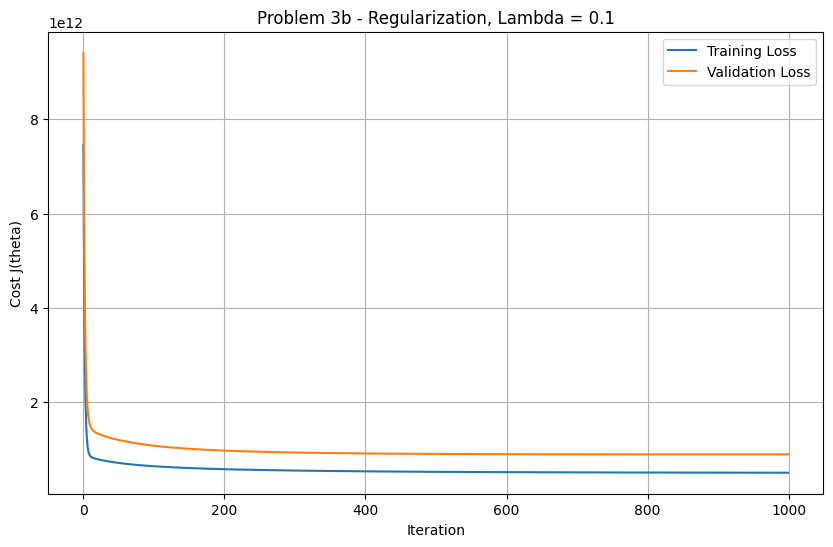

Lambda: 1
Theta: [1900563.23952085 2796088.94542589  786167.01049676 2788723.16159659
 1242479.04765552  479021.22928122  291412.56263075  413403.09800891
  697124.61862302  843144.27676139  861042.73331479  644538.65756541]
Final Training Cost: 527685357698.02246
Final Validation Cost: 900501700678.874

Lambda: 10
Theta: [2259313.21650141 1718638.95199377  663088.19977299 1824335.74557967
 1138467.70635281  529971.74737822  352976.09257908  386602.74058026
  528734.85573139  904378.09766267  902133.8746352   631393.04586751]
Final Training Cost: 685497897876.5576
Final Validation Cost: 1008359342032.3333



In [48]:
lambda_values_3b = [0, 0.001, 0.01, 0.05, 0.1, 1, 10]
alpha = 0.1
iterations = 1000

final_validation_losses_3b = []

for lambda_value in lambda_values_3b:
    theta_3b = np.zeros(12)

    theta_3b, train_cost_3b, test_cost_3b = gradient_descent_regularized(
        X_2b_train_norm_bias,
        y_2b_train,
        X_2b_test_norm_bias,
        y_2b_test,
        theta_3b,
        alpha,
        iterations,
        lambda_value
    )

    final_validation_losses_3b.append(test_cost_3b[-1])

    print("Lambda:", lambda_value)
    print("Theta:", theta_3b)
    print("Final Training Cost:", train_cost_3b[-1])
    print("Final Validation Cost:", test_cost_3b[-1])
    print()

    # Representative regularized training curve
    if lambda_value == 0.1:
        plt.figure(figsize=(10, 6))
        plt.plot(train_cost_3b, label='Training Loss')
        plt.plot(test_cost_3b, label='Validation Loss')
        plt.xlabel('Iteration')
        plt.ylabel('Cost J(theta)')
        plt.title('Problem 3b - Regularization, Lambda = 0.1')
        plt.legend()
        plt.grid(True)
        plt.show()


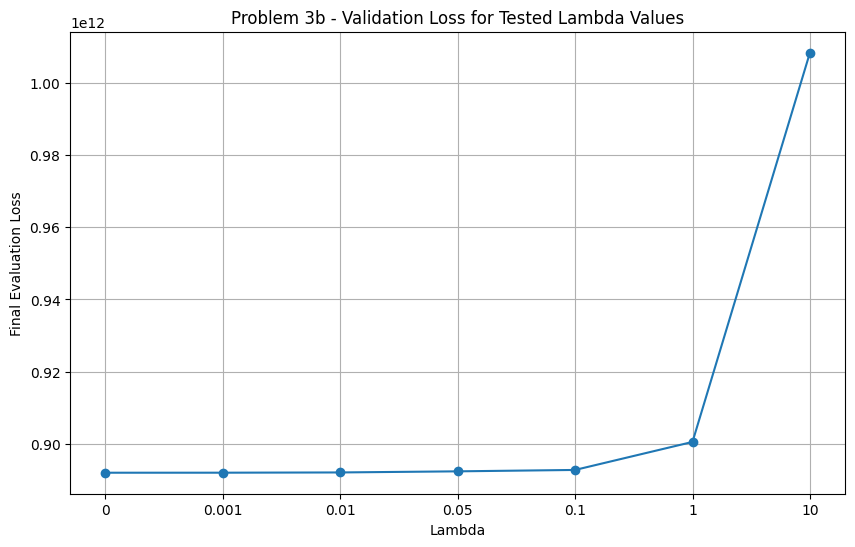

In [49]:
# Compare final validation loss for all tested lambda values
lambda_labels_3b = [str(value) for value in lambda_values_3b]

plt.figure(figsize=(10, 6))
plt.plot(lambda_labels_3b, final_validation_losses_3b, marker='o')

plt.xlabel('Lambda')
plt.ylabel('Final Evaluation Loss')
plt.title('Problem 3b - Validation Loss for Tested Lambda Values')
plt.grid(True)
plt.show()


## Problem 3b result

As in Problem 3a, positive L2 regularization does not improve the validation loss.  
The best evaluation result is obtained with `lambda = 0`, while strong regularization (for example `lambda = 10`) clearly worsens performance.
